<a href="https://colab.research.google.com/github/naveed82/my-data-project/blob/main/Data_cleaning_steps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/german_credit.csv'
df = pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,Creditability,Account Balance,Duration of Credit (month),Payment Status of Previous Credit,Purpose,Credit Amount,Value Savings/Stocks,Length of current employment,Instalment per cent,Sex & Marital Status,...,Duration in Current address,Most valuable available asset,Age (years),Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [ ]:
print("\nData Types of Attributes:")
print(df.dtypes)

# Optional: categorize columns manually
nominal = ['column1', 'column2']     # e.g., categorical columns
ordinal = ['column3']                # e.g., low < medium < high
quantitative = df.select_dtypes(include=[np.number]).columns.tolist()


Data Types of Attributes:
Creditability                        int64
Account Balance                      int64
Duration of Credit (month)           int64
Payment Status of Previous Credit    int64
Purpose                              int64
Credit Amount                        int64
Value Savings/Stocks                 int64
Length of current employment         int64
Instalment per cent                  int64
Sex & Marital Status                 int64
Guarantors                           int64
Duration in Current address          int64
Most valuable available asset        int64
Age (years)                          int64
Concurrent Credits                   int64
Type of apartment                    int64
No of Credits at this Bank           int64
Occupation                           int64
No of dependents                     int64
Telephone                            int64
Foreign Worker                       int64
dtype: object


In [ ]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
Creditability                        0
Account Balance                      0
Duration of Credit (month)           0
Payment Status of Previous Credit    0
Purpose                              0
Credit Amount                        0
Value Savings/Stocks                 0
Length of current employment         0
Instalment per cent                  0
Sex & Marital Status                 0
Guarantors                           0
Duration in Current address          0
Most valuable available asset        0
Age (years)                          0
Concurrent Credits                   0
Type of apartment                    0
No of Credits at this Bank           0
Occupation                           0
No of dependents                     0
Telephone                            0
Foreign Worker                       0
dtype: int64


In [ ]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       Creditability  Account Balance  Duration of Credit (month)  \
count    1000.000000      1000.000000                 1000.000000   
mean        0.700000         2.577000                   20.903000   
std         0.458487         1.257638                   12.058814   
min         0.000000         1.000000                    4.000000   
25%         0.000000         1.000000                   12.000000   
50%         1.000000         2.000000                   18.000000   
75%         1.000000         4.000000                   24.000000   
max         1.000000         4.000000                   72.000000   

       Payment Status of Previous Credit      Purpose  Credit Amount  \
count                         1000.00000  1000.000000     1000.00000   
mean                             2.54500     2.828000     3271.24800   
std                              1.08312     2.744439     2822.75176   
min                              0.00000     0.000000      250.00

In [ ]:
quantitative = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
quantitative.remove('Creditability')  # Exclude target variable if needed

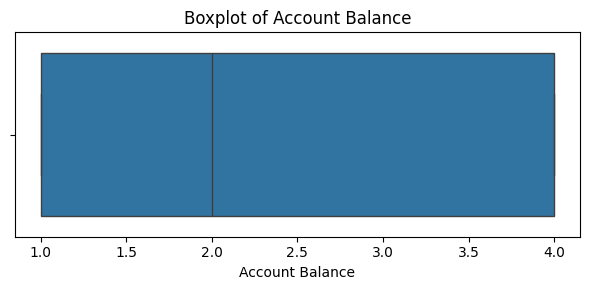

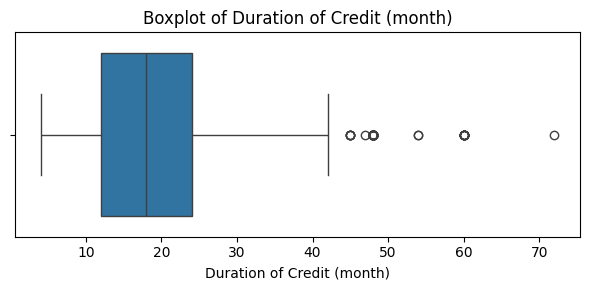

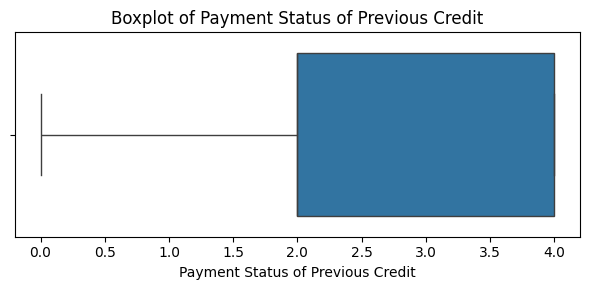

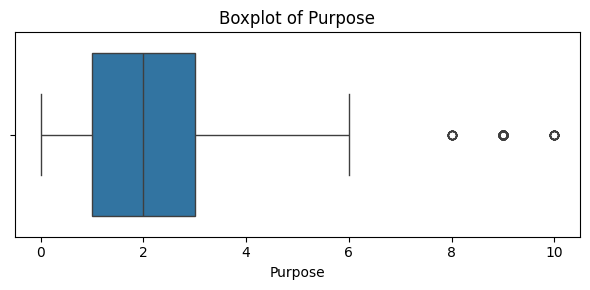

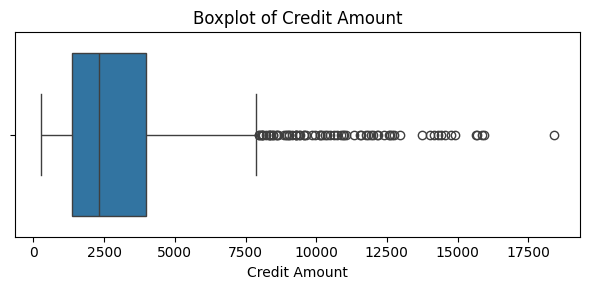

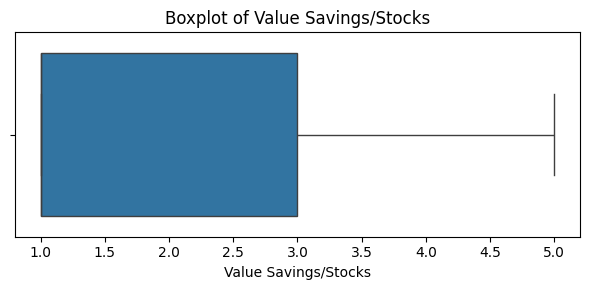

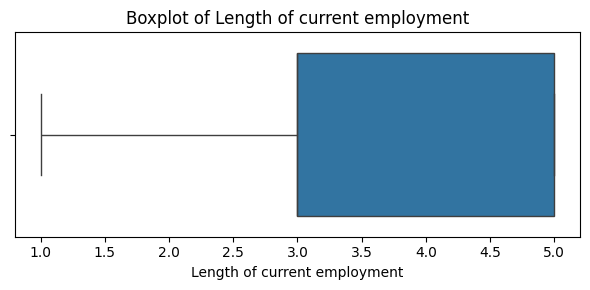

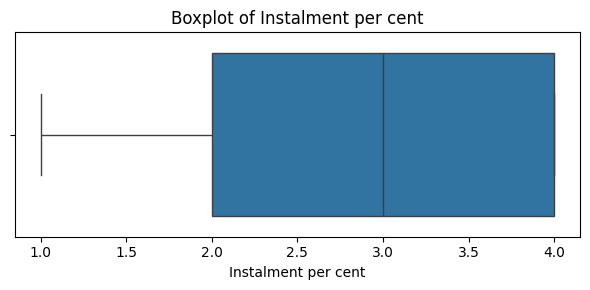

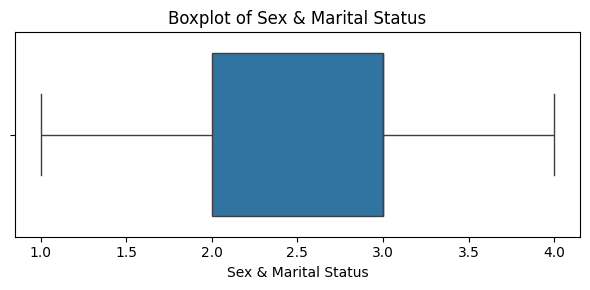

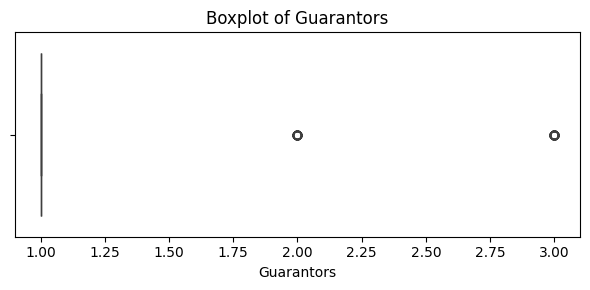

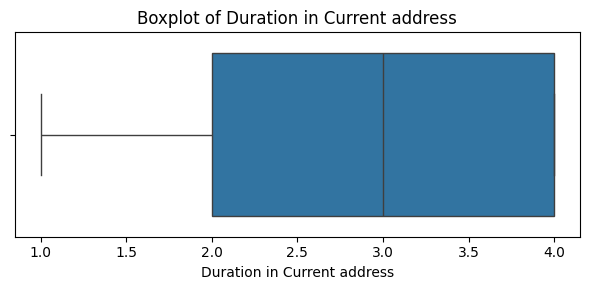

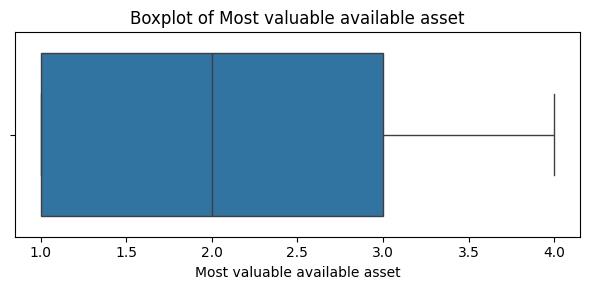

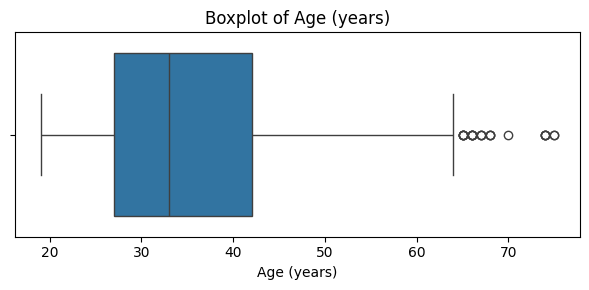

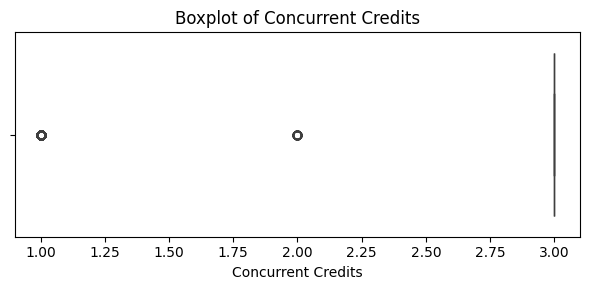

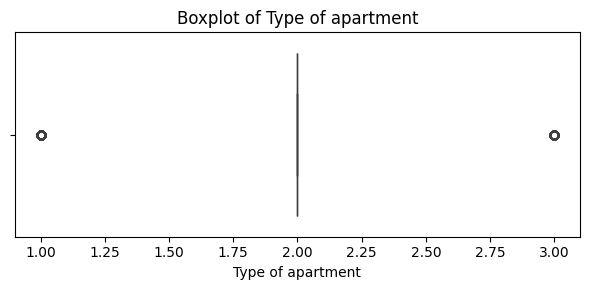

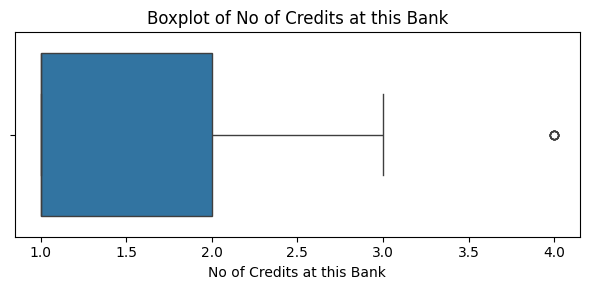

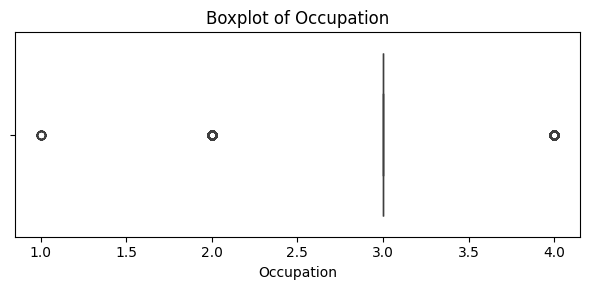

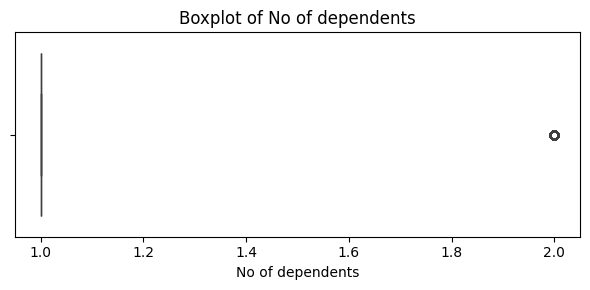

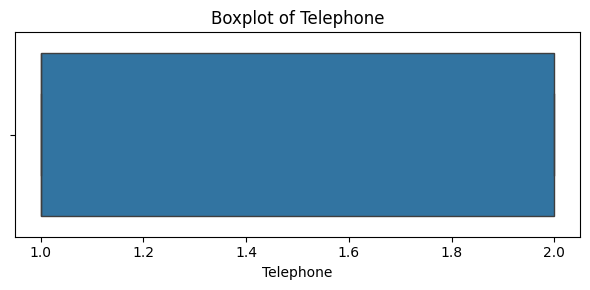

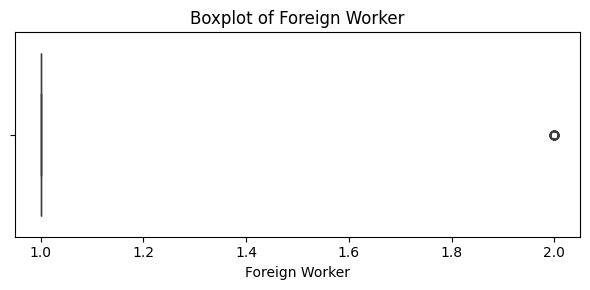

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for each quantitative feature
for col in quantitative:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

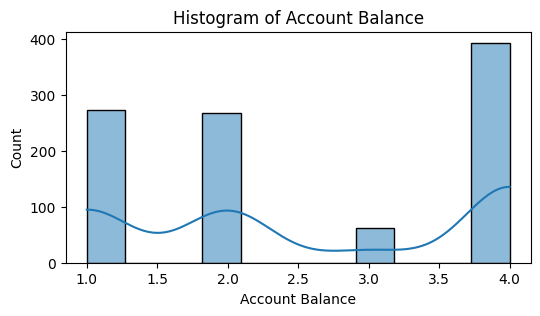

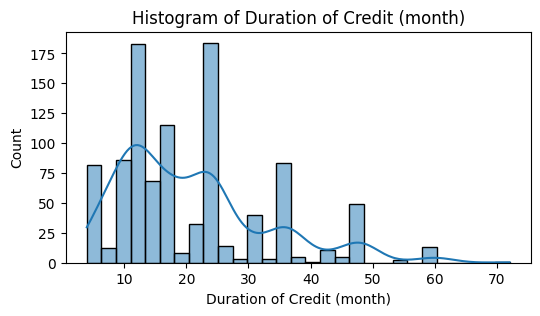

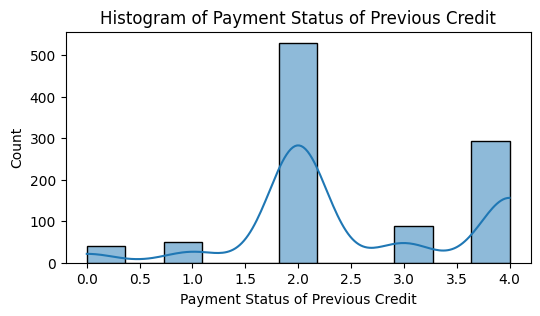

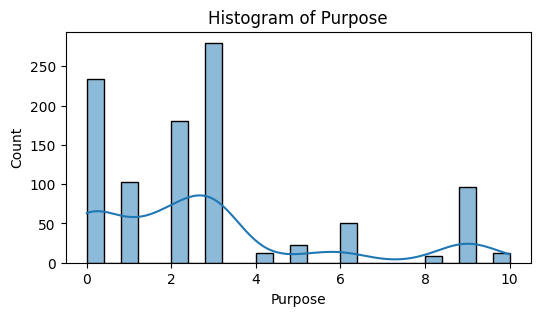

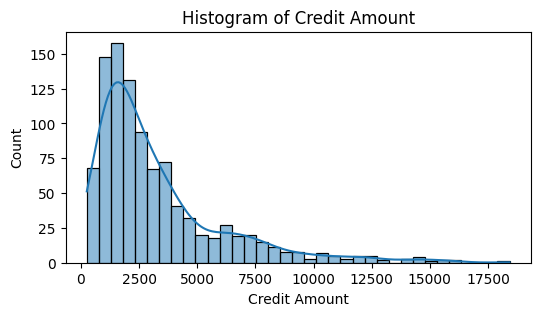

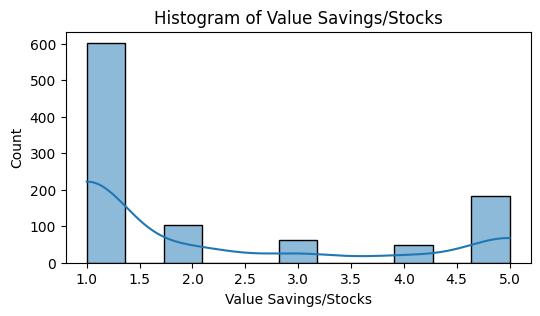

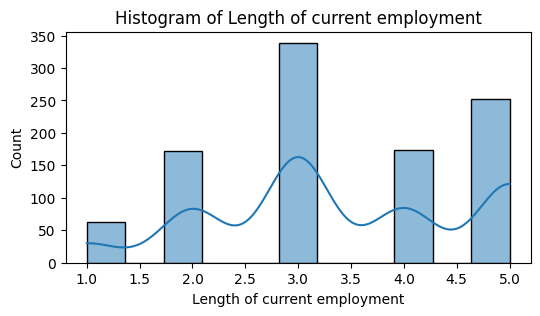

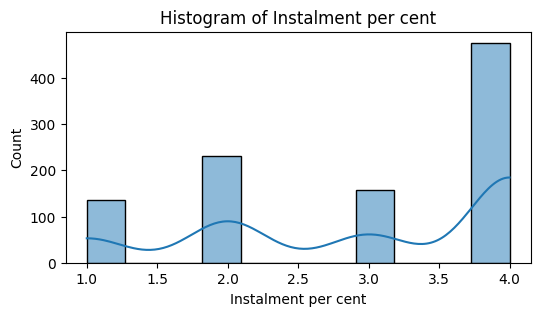

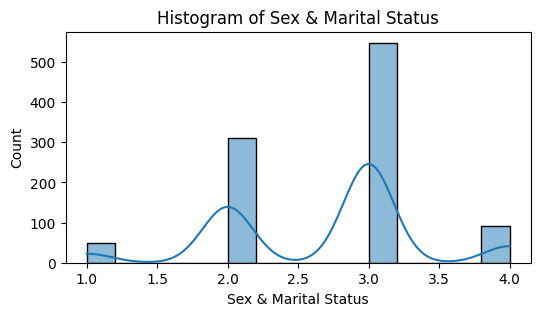

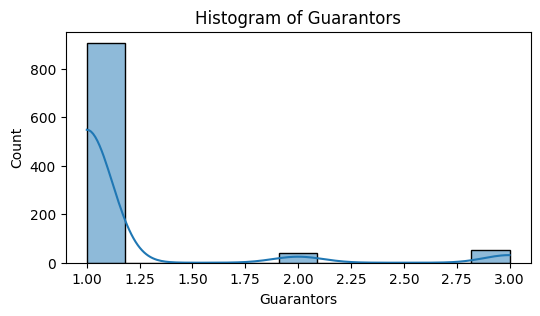

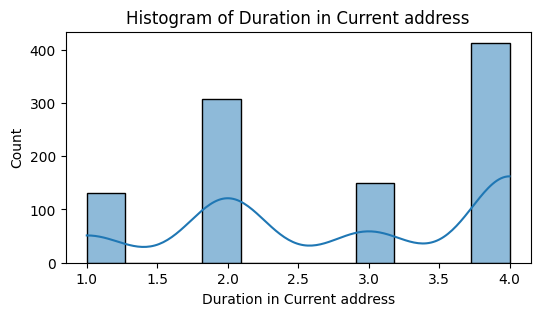

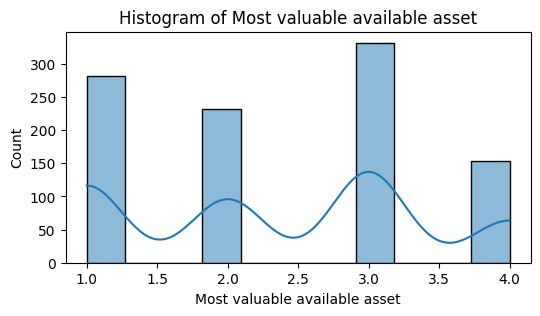

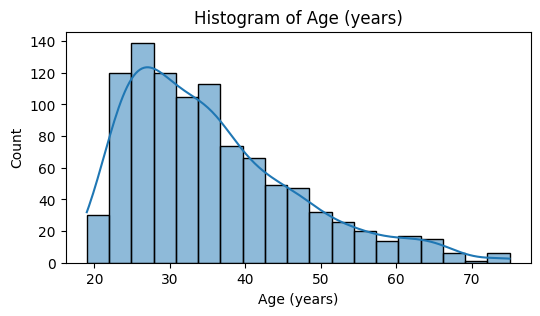

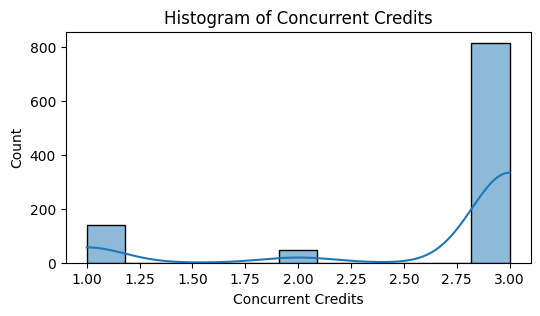

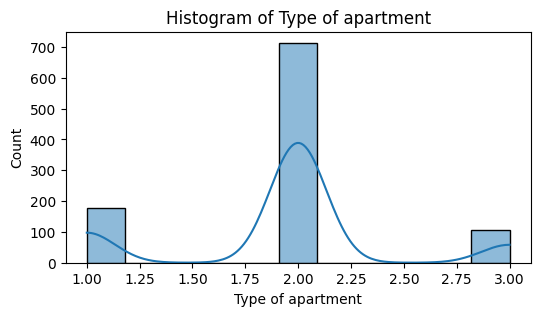

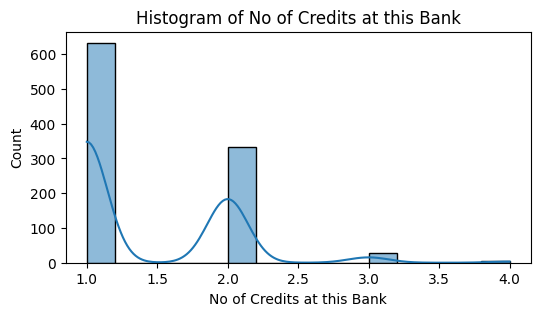

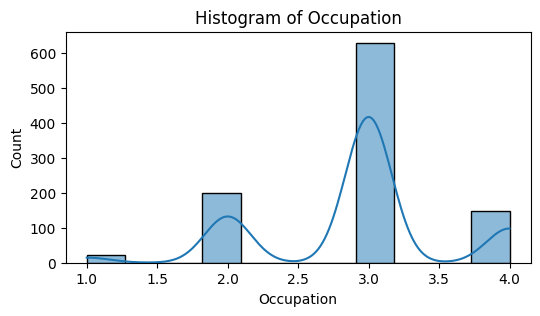

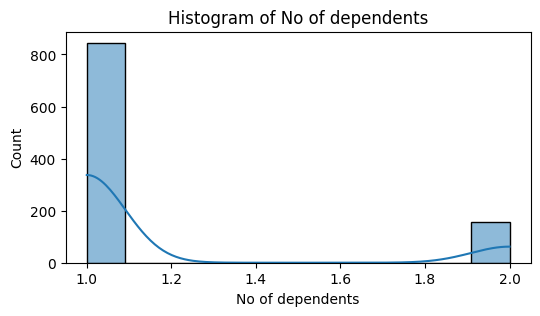

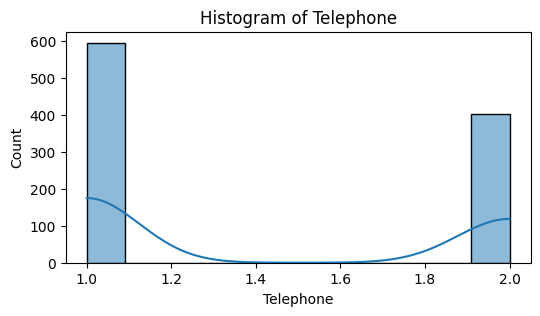

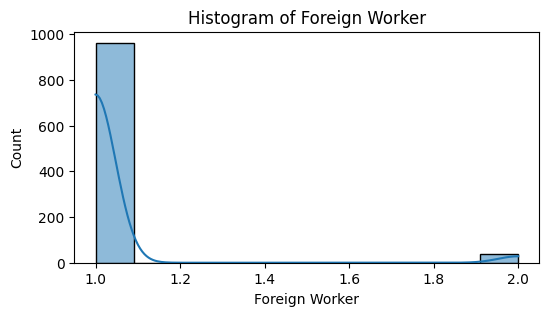

In [ ]:
# Histograms
for col in quantitative:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

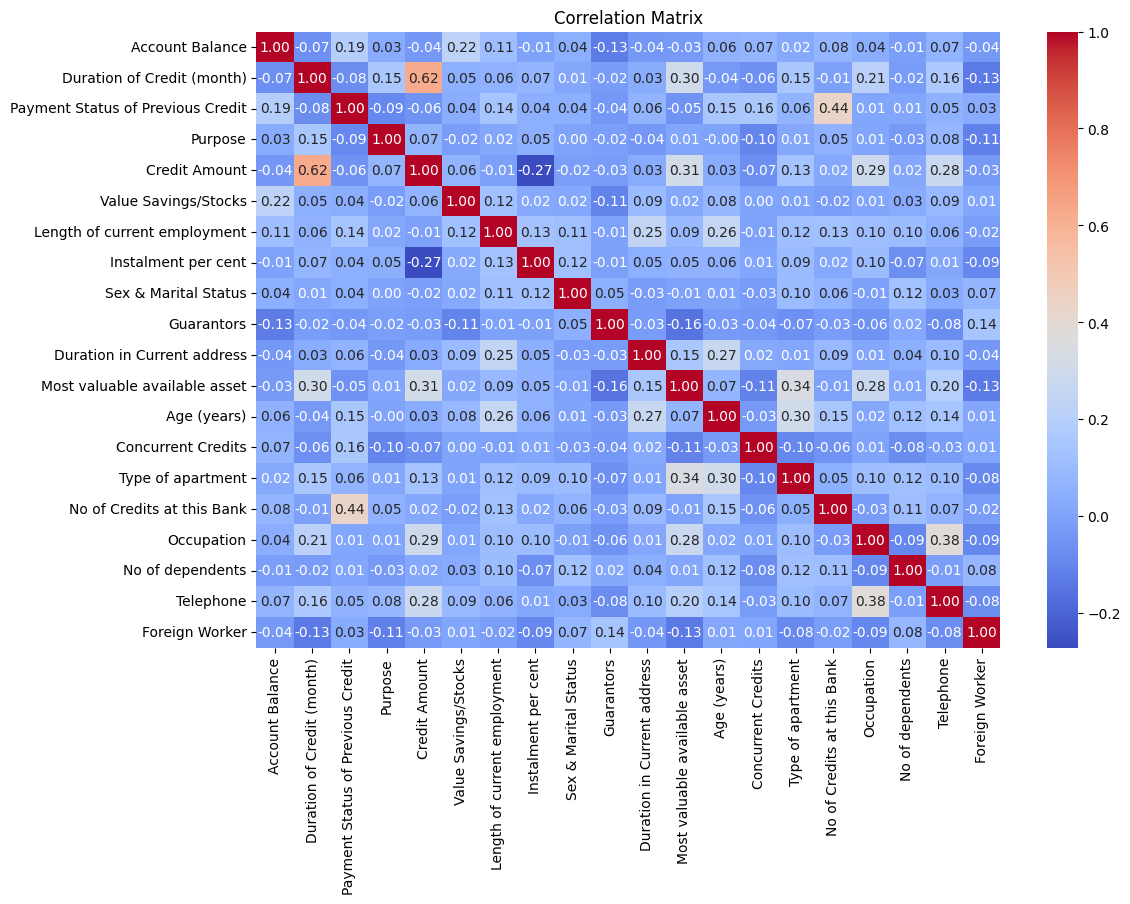

In [ ]:
# Correlation for categories
plt.figure(figsize=(12, 8))
correlation = df[quantitative].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


Class Distribution:
Creditability
1    0.7
0    0.3
Name: proportion, dtype: float64


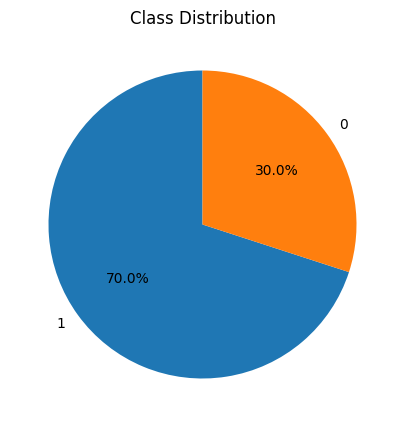

In [ ]:
target = 'Creditability'

print("\nClass Distribution:")
print(df[target].value_counts(normalize=True))

# Optional: Pie chart
df[target].value_counts().plot.pie(
    autopct='%1.1f%%', startangle=90, figsize=(5, 5), title='Class Distribution'
)
plt.ylabel('')
plt.show()

In [ ]:
categorical_cols = ['Purpose', 'Sex & Marital Status', 'Guarantors',
                    'Most valuable available asset', 'Type of apartment',
                    'Telephone', 'Foreign Worker']

numeric_cols = ['Account Balance', 'Duration of Credit (month)', 'Credit Amount',
                'Length of current employment', 'Instalment per cent',
                'Duration in Current address', 'Age (years)',
                'No of Credits at this Bank', 'No of dependents']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.head())


   Creditability  Account Balance  Duration of Credit (month)  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment Status of Previous Credit  Credit Amount  Value Savings/Stocks  \
0                                  4           1049                     1   
1                                  4           2799                     1   
2                                  2            841                     2   
3                                  4           2122                     1   
4                                  4           2171                     1   

   Length of current employment  Instalment per cent  \
0                             2                    4   
1                             3   

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
numeric_cols = ['Account Balance', 'Duration of Credit (month)', 'Credit Amount',
                'Length of current employment', 'Instalment per cent',
                'Duration in Current address', 'Age (years)', 'No of Credits at this Bank',
                'No of dependents']
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print("Standardized numeric columns:")
print(df_encoded[numeric_cols].head())


Standardized numeric columns:
   Account Balance  Duration of Credit (month)  Credit Amount  \
0        -1.254566                   -0.240857      -0.787657   
1        -1.254566                   -0.987573      -0.167384   
2        -0.459026                   -0.738668      -0.861381   
3        -1.254566                   -0.738668      -0.407341   
4        -1.254566                   -0.738668      -0.389974   

   Length of current employment  Instalment per cent  \
0                     -1.145978             0.918477   
1                     -0.317959            -0.870183   
2                      0.510060            -0.870183   
3                     -0.317959             0.024147   
4                     -0.317959             0.918477   

   Duration in Current address  Age (years)  No of Credits at this Bank  \
0                     1.046987    -1.281573                   -0.704926   
1                    -0.765977     0.040363                    1.027079   
2                

In [ ]:
df_encoded.to_csv('standardized_data.csv', index=False)
from google.colab import files
files.download('standardized_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>